In [1]:
import pandas as pd
import numpy as np

import time
import sys
import hashlib

import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict

In [2]:
from google.colab import files

uploaded = files.upload()

Saving ratings.dat to ratings.dat


In [3]:
ratings = pd.read_csv(

    'ratings.dat',

    sep='::',

    engine='python',

    names=[

        'UserID',
        'MovieID',
        'Rating',
        'Timestamp'
    ]
)

ratings.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [6]:
print(
    "데이터 shape:"
)

print(
    ratings.shape
)

ratings.info()

데이터 shape:
(1000209, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     1000209 non-null  int64
 1   MovieID    1000209 non-null  int64
 2   Rating     1000209 non-null  int64
 3   Timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [9]:
# 결측치 확인

missing_values = (
    ratings
    .isnull()
    .sum()
)

print(
    missing_values
)

UserID       0
MovieID      0
Rating       0
Timestamp    0
dtype: int64


In [10]:
# 전체 데이터를 한 번에 메모리에 올리지 않는 방식

def rating_stream(file_path):

    with open(
        file_path,
        'r',
        encoding='latin-1'
    ) as file:

        for line in file:

            line = (
                line
                .strip()
                .split('::')
            )

            yield {

                'UserID':
                int(line[0]),

                'MovieID':
                int(line[1]),

                'Rating':
                int(line[2]),

                'Timestamp':
                int(line[3])
            }

In [11]:
# 스트림 테스트

stream = rating_stream(
    'ratings.dat'
)

for i in range(5):

    print(
        next(stream)
    )

{'UserID': 1, 'MovieID': 1193, 'Rating': 5, 'Timestamp': 978300760}
{'UserID': 1, 'MovieID': 661, 'Rating': 3, 'Timestamp': 978302109}
{'UserID': 1, 'MovieID': 914, 'Rating': 3, 'Timestamp': 978301968}
{'UserID': 1, 'MovieID': 3408, 'Rating': 4, 'Timestamp': 978300275}
{'UserID': 1, 'MovieID': 2355, 'Rating': 5, 'Timestamp': 978824291}


In [12]:
# Bloom Filter 구현

class BloomFilter:

    def __init__(
        self,
        size=1000000,
        num_hashes=5
    ):

        self.size = size

        self.num_hashes = num_hashes

        self.bit_array = np.zeros(
            size,
            dtype=bool
        )

    def _hashes(
        self,
        item
    ):

        hashes = []

        for i in range(
            self.num_hashes
        ):

            hash_value = int(

                hashlib.md5(

                    (
                        str(item)
                        + str(i)
                    ).encode()

                ).hexdigest(),

                16
            )

            hashes.append(
                hash_value
                % self.size
            )

        return hashes

    def add(
        self,
        item
    ):

        for hash_idx in (
            self._hashes(item)
        ):

            self.bit_array[
                hash_idx
            ] = True

    def contains(
        self,
        item
    ):

        for hash_idx in (
            self._hashes(item)
        ):

            if not self.bit_array[
                hash_idx
            ]:

                return False

        return True

In [15]:
# Bloom Filter 테스트

bf = BloomFilter()

bf.add("movie_1")

print(
    bf.contains(
        "movie_1"
    )
)

print(
    bf.contains(
        "movie_999"
    )
)

True
False


In [16]:
# Count-Min Sketch 구현

class CountMinSketch:

    def __init__(
        self,
        width=5000,
        depth=5
    ):

        self.width = width
        self.depth = depth

        self.table = np.zeros(

            (
                depth,
                width
            ),

            dtype=int
        )

    def _hash(
        self,
        item,
        seed
    ):

        hash_value = int(

            hashlib.md5(

                (
                    str(item)
                    + str(seed)
                ).encode()

            ).hexdigest(),

            16
        )

        return (
            hash_value
            % self.width
        )

    def add(
        self,
        item
    ):

        for i in range(
            self.depth
        ):

            idx = self._hash(
                item,
                i
            )

            self.table[
                i,
                idx
            ] += 1

    def estimate(
        self,
        item
    ):

        estimates = []

        for i in range(
            self.depth
        ):

            idx = self._hash(
                item,
                i
            )

            estimates.append(

                self.table[
                    i,
                    idx
                ]
            )

        return min(
            estimates
        )

In [17]:
# Count-Min Sketch 테스트

cms = CountMinSketch()

cms.add(100)

cms.add(100)

cms.add(100)

cms.add(200)

print(
    cms.estimate(
        100
    )
)

print(
    cms.estimate(
        200
    )
)

3
1


In [18]:
# Bloom Filter용 Ground Truth 생성

true_set = set()

stream = rating_stream(
    'ratings.dat'
)

for row in stream:

    item = (

        row['UserID'],
        row['MovieID']
    )

    true_set.add(
        item
    )

print(
    "Ground Truth Set Size:"
)

print(
    len(true_set)
)

Ground Truth Set Size:
1000209


In [19]:
# Count-Min Sketch용 Ground Truth

true_frequency = defaultdict(
    int
)

stream = rating_stream(
    'ratings.dat'
)

for row in stream:

    movie_id = (
        row['MovieID']
    )

    true_frequency[
        movie_id
    ] += 1

print(
    "Unique Movie Count:"
)

print(
    len(true_frequency)
)

Unique Movie Count:
3706


In [20]:
# Ground Truth 확인

sample_movies = list(

    true_frequency.keys()

)[:10]

for movie in sample_movies:

    print(

        f"Movie {movie}:",

        true_frequency[
            movie
        ]
    )

Movie 1193: 1725
Movie 661: 525
Movie 914: 636
Movie 3408: 1315
Movie 2355: 1703
Movie 1197: 2318
Movie 1287: 704
Movie 2804: 1352
Movie 594: 763
Movie 919: 1718


In [21]:
# 스트림 처리 속도 측정 준비

def measure_time(
    func,
    *args
):

    start = time.time()

    result = func(
        *args
    )

    end = time.time()

    return (

        result,

        end - start
    )

In [22]:
# Bloom Filter 실험

def run_bloom_experiment(

    size,
    num_hashes
):

    bf = BloomFilter(

        size=size,

        num_hashes=num_hashes
    )

    start_time = time.time()

    stream = rating_stream(
        'ratings.dat'
    )

    inserted_items = set()

    for row in stream:

        item = (

            row['UserID'],
            row['MovieID']
        )

        bf.add(item)

        inserted_items.add(
            item
        )

    process_time = (
        time.time()
        - start_time
    )

    false_positive = 0
    total_test = 10000

    np.random.seed(42)

    for _ in range(
        total_test
    ):

        fake_item = (

            np.random.randint(
                10000,
                20000
            ),

            np.random.randint(
                10000,
                20000
            )
        )

        if fake_item not in inserted_items:

            if bf.contains(
                fake_item
            ):

                false_positive += 1

    false_positive_rate = (

        false_positive
        / total_test
    )

    memory_usage = (
        bf.bit_array.nbytes
        / 1024
    )

    return {

        'bit_size': size,

        'hash_count':
        num_hashes,

        'false_positive_rate':
        false_positive_rate,

        'memory_kb':
        memory_usage,

        'time_sec':
        process_time
    }

In [23]:
# 파라미터 실험 수행

bloom_results = []

bloom_params = [

    (100000, 3),

    (500000, 5),

    (1000000, 7)
]

for size, hashes in bloom_params:

    print(
        f"실험 중: "
        f"size={size}, "
        f"hash={hashes}"
    )

    result = run_bloom_experiment(

        size=size,

        num_hashes=hashes
    )

    bloom_results.append(
        result
    )

실험 중: size=100000, hash=3
실험 중: size=500000, hash=5
실험 중: size=1000000, hash=7


In [24]:
# 결과 테이블

bloom_df = pd.DataFrame(
    bloom_results
)

bloom_df

,bit_size,hash_count,false_positive_rate,memory_kb,time_sec
0,100000,3,1.0000,97.65625,8.964992
1,500000,5,0.9996,488.28125,14.279828
2,1000000,7,0.9918,976.56250,20.761330


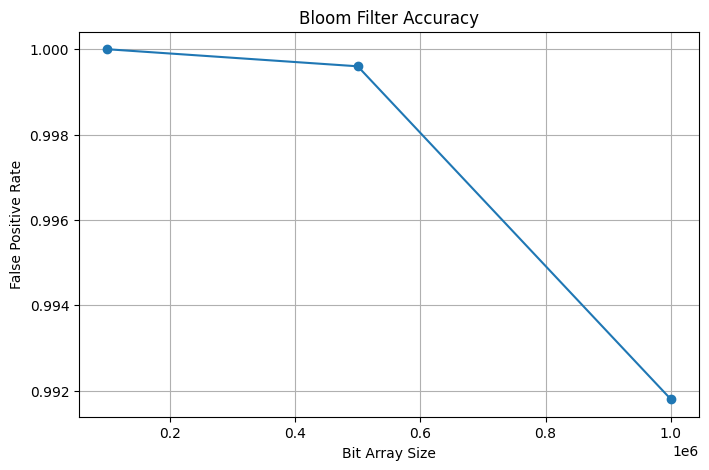

In [25]:
# 정확도 그래프

plt.figure(
    figsize=(8,5)
)

plt.plot(

    bloom_df['bit_size'],

    bloom_df[
        'false_positive_rate'
    ],

    marker='o'
)

plt.xlabel(
    'Bit Array Size'
)

plt.ylabel(
    'False Positive Rate'
)

plt.title(
    'Bloom Filter Accuracy'
)

plt.grid(True)

plt.show()

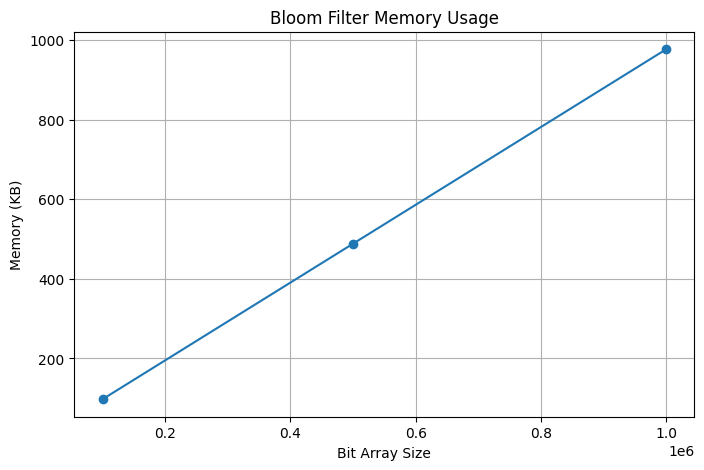

In [26]:
# 메모리 사용량 그래프

plt.figure(
    figsize=(8,5)
)

plt.plot(

    bloom_df['bit_size'],

    bloom_df[
        'memory_kb'
    ],

    marker='o'
)

plt.xlabel(
    'Bit Array Size'
)

plt.ylabel(
    'Memory (KB)'
)

plt.title(
    'Bloom Filter Memory Usage'
)

plt.grid(True)

plt.show()

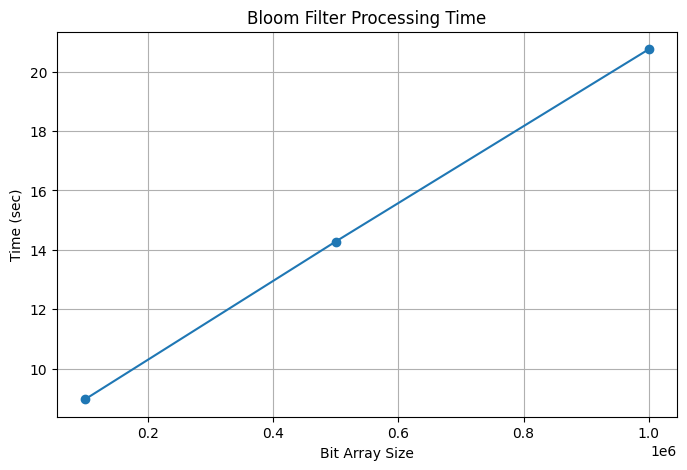

In [27]:
# 처리 시간 그래프

plt.figure(
    figsize=(8,5)
)

plt.plot(

    bloom_df['bit_size'],

    bloom_df[
        'time_sec'
    ],

    marker='o'
)

plt.xlabel(
    'Bit Array Size'
)

plt.ylabel(
    'Time (sec)'
)

plt.title(
    'Bloom Filter Processing Time'
)

plt.grid(True)

plt.show()

In [28]:
# Count-Min Sketch 실험

def run_cms_experiment(

    width,
    depth
):

    cms = CountMinSketch(

        width=width,

        depth=depth
    )

    start_time = time.time()

    stream = rating_stream(
        'ratings.dat'
    )

    for row in stream:

        movie_id = (
            row['MovieID']
        )

        cms.add(
            movie_id
        )

    process_time = (
        time.time()
        - start_time
    )

    relative_errors = []

    sample_movies = list(

        true_frequency.keys()

    )[:1000]

    for movie in sample_movies:

        true_count = (

            true_frequency[
                movie
            ]
        )

        estimated_count = (

            cms.estimate(
                movie
            )
        )

        error = abs(

            estimated_count
            - true_count

        ) / true_count

        relative_errors.append(
            error
        )

    avg_relative_error = np.mean(
        relative_errors
    )

    memory_usage = (

        cms.table.nbytes
        / 1024
    )

    return {

        'width': width,

        'depth': depth,

        'relative_error':
        avg_relative_error,

        'memory_kb':
        memory_usage,

        'time_sec':
        process_time
    }

In [29]:
# 파라미터 실험 수행

cms_results = []

cms_params = [

    (1000, 3),

    (5000, 5),

    (10000, 7)
]

for width, depth in cms_params:

    print(

        f"실험 중: "

        f"width={width}, "

        f"depth={depth}"
    )

    result = run_cms_experiment(

        width,

        depth
    )

    cms_results.append(
        result
    )

실험 중: width=1000, depth=3
실험 중: width=5000, depth=5
실험 중: width=10000, depth=7


In [30]:
# 결과 테이블

cms_df = pd.DataFrame(
    cms_results
)

cms_df

,width,depth,relative_error,memory_kb,time_sec
0,1000,3,1.528035,23.4375,9.413944
1,5000,5,0.016692,195.3125,13.589995
2,10000,7,0.000000,546.8750,17.777015


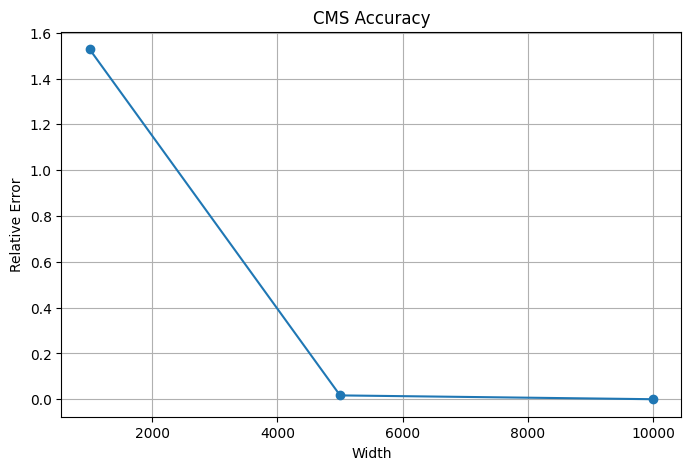

In [31]:
# 정확도 그래프

plt.figure(
    figsize=(8,5)
)

plt.plot(

    cms_df['width'],

    cms_df[
        'relative_error'
    ],

    marker='o'
)

plt.xlabel(
    'Width'
)

plt.ylabel(
    'Relative Error'
)

plt.title(
    'CMS Accuracy'
)

plt.grid(True)

plt.show()

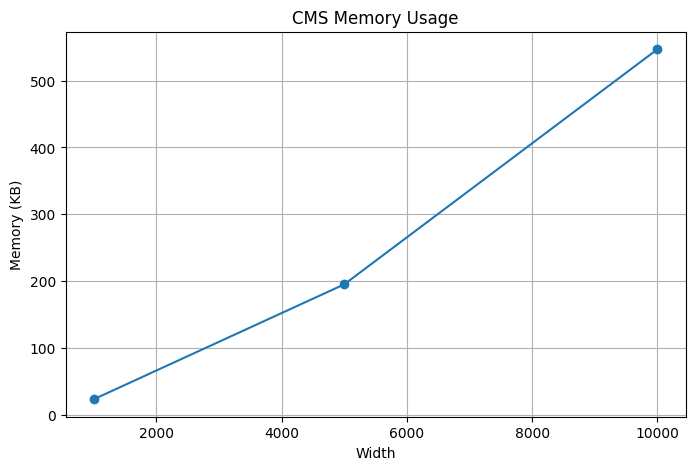

In [32]:
# 메모리 사용량 그래프

plt.figure(
    figsize=(8,5)
)

plt.plot(

    cms_df['width'],

    cms_df[
        'memory_kb'
    ],

    marker='o'
)

plt.xlabel(
    'Width'
)

plt.ylabel(
    'Memory (KB)'
)

plt.title(
    'CMS Memory Usage'
)

plt.grid(True)

plt.show()

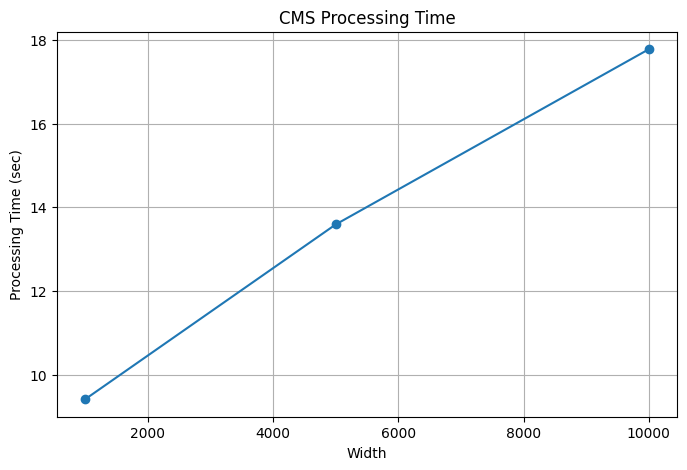

In [33]:
# 처리 시간 그래프

plt.figure(
    figsize=(8,5)
)

plt.plot(

    cms_df['width'],

    cms_df[
        'time_sec'
    ],

    marker='o'
)

plt.xlabel(
    'Width'
)

plt.ylabel(
    'Processing Time (sec)'
)

plt.title(
    'CMS Processing Time'
)

plt.grid(True)

plt.show()

In [34]:
# 최종 결과 테이블

final_comparison = pd.DataFrame({

    'Algorithm': [

        'Bloom Filter',

        'Count-Min Sketch'
    ],

    'Accuracy Metric': [

        bloom_df[
            'false_positive_rate'
        ].iloc[-1],

        cms_df[
            'relative_error'
        ].iloc[-1]
    ],

    'Memory (KB)': [

        bloom_df[
            'memory_kb'
        ].iloc[-1],

        cms_df[
            'memory_kb'
        ].iloc[-1]
    ],

    'Processing Time (sec)': [

        bloom_df[
            'time_sec'
        ].iloc[-1],

        cms_df[
            'time_sec'
        ].iloc[-1]
    ]
})

final_comparison

,Algorithm,Accuracy Metric,Memory (KB),Processing Time (sec)
0,Bloom Filter,0.9918,976.5625,20.761330
1,Count-Min Sketch,0.0000,546.8750,17.777015


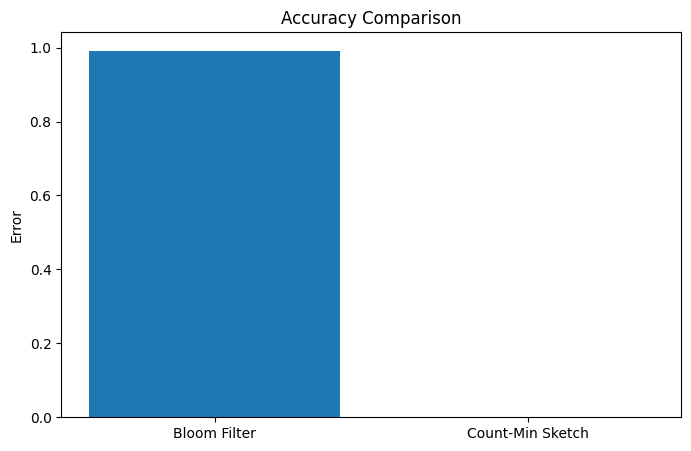

In [35]:
# 최종 정확도 비교 그래프

plt.figure(
    figsize=(8,5)
)

algorithms = [

    'Bloom Filter',

    'Count-Min Sketch'
]

accuracy_values = [

    bloom_df[
        'false_positive_rate'
    ].iloc[-1],

    cms_df[
        'relative_error'
    ].iloc[-1]
]

plt.bar(

    algorithms,

    accuracy_values
)

plt.ylabel(
    'Error'
)

plt.title(
    'Accuracy Comparison'
)

plt.show()

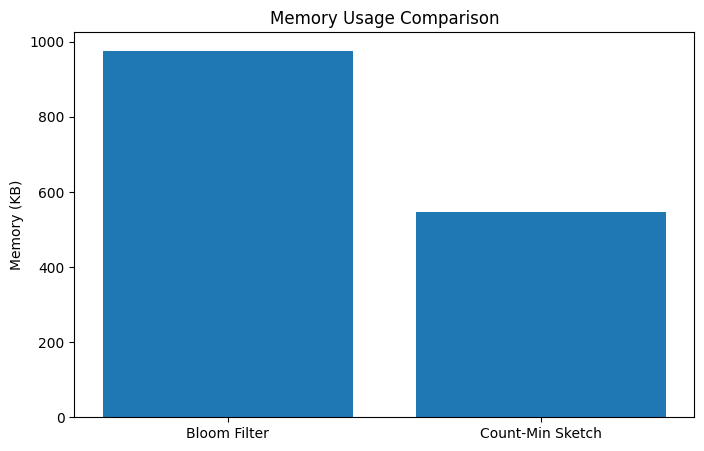

In [36]:
# 최종 메모리 사용량 비교 그래프

plt.figure(
    figsize=(8,5)
)

memory_values = [

    bloom_df[
        'memory_kb'
    ].iloc[-1],

    cms_df[
        'memory_kb'
    ].iloc[-1]
]

plt.bar(

    algorithms,

    memory_values
)

plt.ylabel(
    'Memory (KB)'
)

plt.title(
    'Memory Usage Comparison'
)

plt.show()

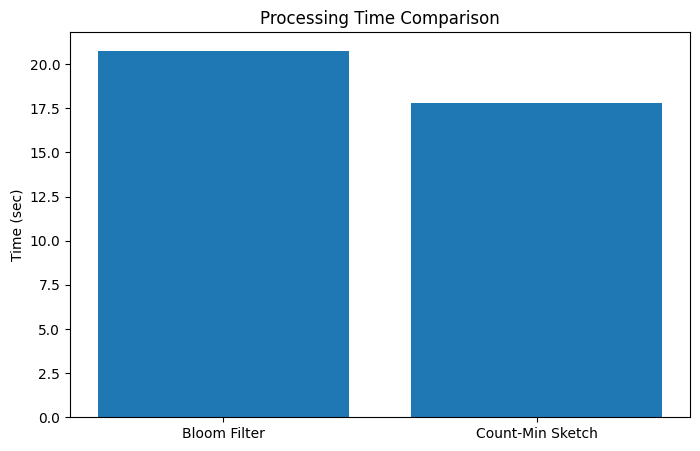

In [37]:
# 최종 처리 시간 비교 그래프

plt.figure(
    figsize=(8,5)
)

time_values = [

    bloom_df[
        'time_sec'
    ].iloc[-1],

    cms_df[
        'time_sec'
    ].iloc[-1]
]

plt.bar(

    algorithms,

    time_values
)

plt.ylabel(
    'Time (sec)'
)

plt.title(
    'Processing Time Comparison'
)

plt.show()